<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/Week_6_Gaurav_Mittal_autoencoder_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder MNIST

## Importing required packages

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [22]:
transforms=transforms.ToTensor()

## Downloading requried data

In [23]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

## Defining dataloaders

In [24]:
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [25]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [ ]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [ ]:
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

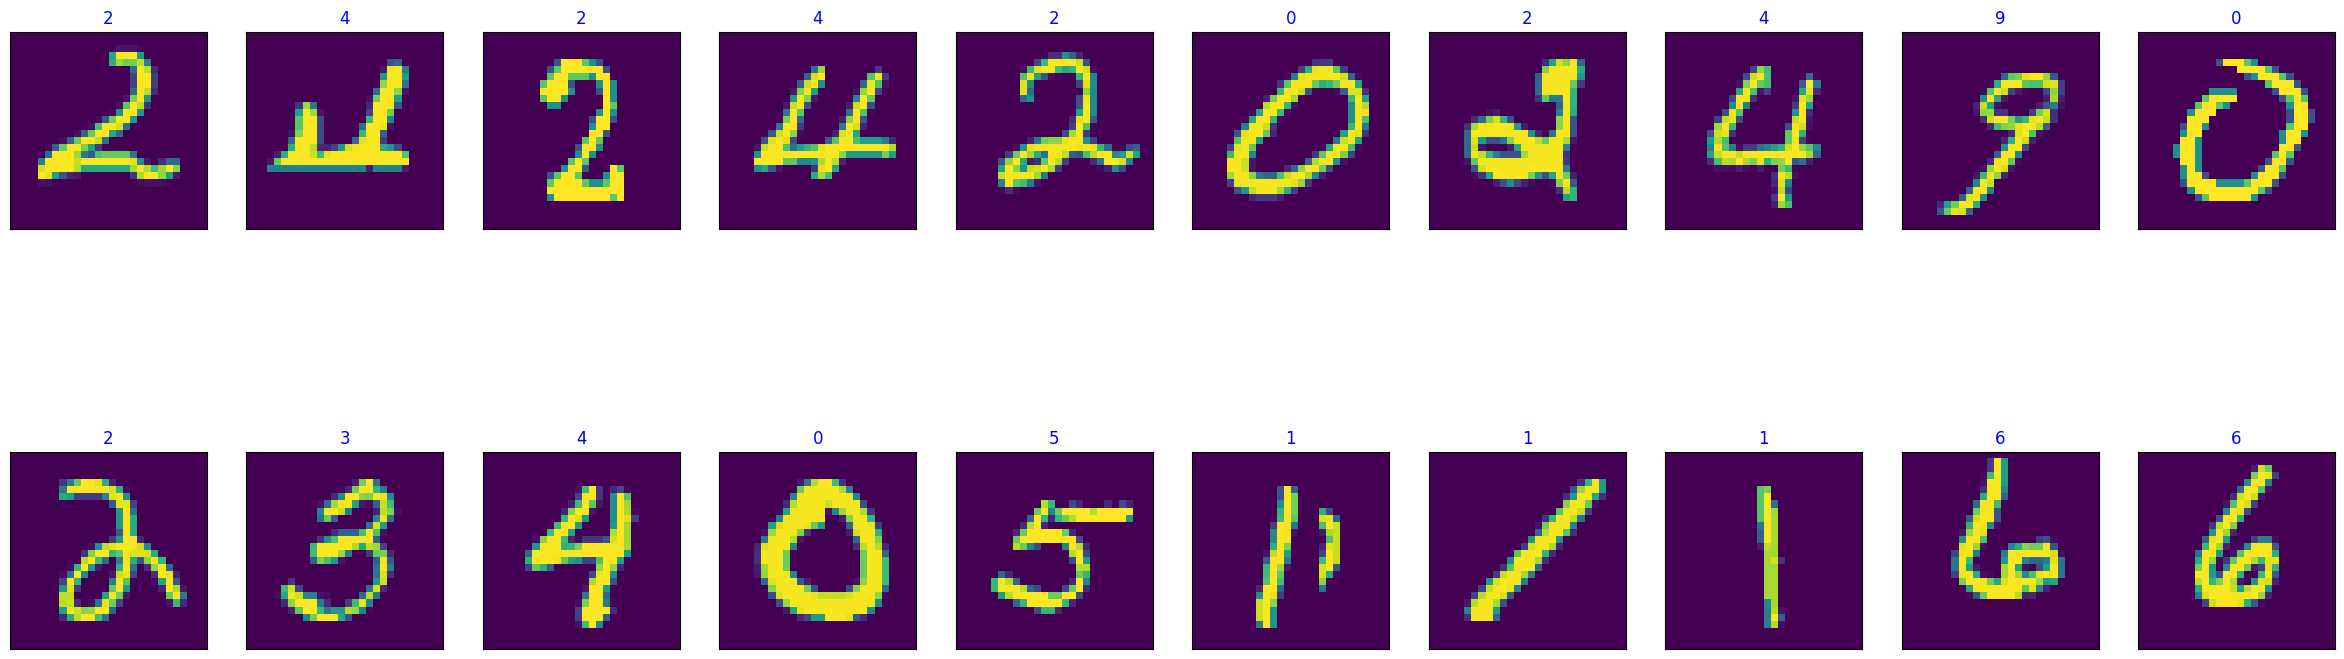

In [ ]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [36]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        # Note: nn.functional.upsample is deprecated. Using nn.functional.interpolate instead.
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [27]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [28]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [29]:
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images # Keep original images as target
            if denoising:
                images = add_gaussian_noise(images, noise_factor) # Add noise to input

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images) # Compare output to original clean images
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images # Keep original images as target
            if denoising:
                images = add_gaussian_noise(images, noise_factor) # Add noise to input

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            output=model(images)
            loss=criterion(output,original_images) # Compare output to original clean images
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model......."
            )
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth') # Save as denoising model
            valid_loss_min=valid_loss
    return(loss_keeper)

In [ ]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.03576896493555978	Validation Loss : 0.03272625260365506
Validation loss decreased from : inf ----> 0.03272625260365506 ----> Saving Model.......

Epoch : 2	Training Loss : 0.03212392647750675	Validation Loss : 0.03210423862872024
Validation loss decreased from : 0.03272625260365506 ----> 0.03210423862872024 ----> Saving Model.......

Epoch : 3	Training Loss : 0.031907087300593655	Validation Loss : 0.031585404050226015
Validation loss decreased from : 0.03210423862872024 ----> 0.031585404050226015 ----> Saving Model.......

Epoch : 4	Training Loss : 0.03184790217550471	Validation Loss : 0.03217885815228025

Epoch : 5	Training Loss : 0.031753125032410026	Validation Loss : 0.03168437038858732

Epoch : 6	Training Loss : 0.03176548581958438	Validation Loss : 0.03191459920878212

Epoch : 7	Training Loss : 0.03171270487907653	Validation Loss : 0.031924656194945174

Epoch : 8	Training Loss : 0.03169317353904868	Validation Loss : 0.03182919300161302

Epoch : 9	Train

In [ ]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.013993923072121106	Validation Loss : 0.009234928002115339
Validation loss decreased from : inf ----> 0.009234928002115339 ----> Saving Model.......

Epoch : 2	Training Loss : 0.009061731391120702	Validation Loss : 0.008749911383880923
Validation loss decreased from : 0.009234928002115339 ----> 0.008749911383880923 ----> Saving Model.......

Epoch : 3	Training Loss : 0.008773517876397819	Validation Loss : 0.008888458318542689

Epoch : 4	Training Loss : 0.00865008338567956	Validation Loss : 0.008527822815037021
Validation loss decreased from : 0.008749911383880923 ----> 0.008527822815037021 ----> Saving Model.......

Epoch : 5	Training Loss : 0.008531558167887851	Validation Loss : 0.008447306758413712
Validation loss decreased from : 0.008527822815037021 ----> 0.008447306758413712 ----> Saving Model.......

Epoch : 6	Training Loss : 0.00845552587066777	Validation Loss : 0.008416220811971773
Validation loss decreased from : 0.008447306758413712 ----> 0.0084162

In [ ]:
m3_loss=trainNet(model_3,0.01,'conv')

/tmp/ipykernel_1437/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_1437/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.009341610934740553	Validation Loss : 0.006632898623744647
Validation loss decreased from : inf ----> 0.006632898623744647 ----> Saving Model.......

Epoch : 2	Training Loss : 0.006512785011630815	Validation Loss : 0.006308211182865004
Validation loss decreased from : 0.006632898623744647 ----> 0.006308211182865004 ----> Saving Model.......

Epoch : 3	Training Loss : 0.006230879274274533	Validation Loss : 0.006040962939926733
Validation loss decreased from : 0.006308211182865004 ----> 0.006040962939926733 ----> Saving Model.......

Epoch : 4	Training Loss : 0.006119331487376864	Validation Loss : 0.006639323859320333

Epoch : 5	Training Loss : 0.006091381874575745	Validation Loss : 0.0060310106895243125
Validation loss decreased from : 0.006040962939926733 ----> 0.0060310106895243125 ----> Saving Model.......

Epoch : 6	Training Loss : 0.006053065106874177	Validation Loss : 0.0059213581308722495
Validation loss decreased from : 0.0060310106895243125 ----> 0.0

In [31]:
# Re-initialize model_3 for denoising training
model_3_denoising = upsamp_conv_Auto_MNIST()

# Apply weight initialization if needed (Transpose CNN doesn't use Linear layers)
# model_3_denoising.apply(weight_init_normal)

# Move model to GPU if available
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

# Train model_3 as a denoising autoencoder
m3_denoising_loss = trainNet(model_3_denoising, 0.01, 'conv', denoising=True, noise_factor=0.3)

/tmp/ipykernel_2257/4075083271.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_2257/4075083271.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.11212089909551044	Validation Loss : 0.11181112598627806
Validation loss decreased from : inf ----> 0.11181112598627806 ----> Saving Model.......

Epoch : 2	Training Loss : 0.11205044266457359	Validation Loss : 0.1118111260732015

Epoch : 3	Training Loss : 0.11205044280116756	Validation Loss : 0.11181112670650085

Epoch : 4	Training Loss : 0.11205044268940886	Validation Loss : 0.11181112624704838

Epoch : 5	Training Loss : 0.11205044276081026	Validation Loss : 0.11181112630913655

Epoch : 6	Training Loss : 0.11205044272355735	Validation Loss : 0.1118111260732015

Epoch : 7	Training Loss : 0.1120504426707824	Validation Loss : 0.11181112653265397

Epoch : 8	Training Loss : 0.11205044290671747	Validation Loss : 0.11181112597386042
Validation loss decreased from : 0.11181112598627806 ----> 0.11181112597386042 ----> Saving Model.......

Epoch : 9	Training Loss : 0.11205044282289843	Validation Loss : 0.1118111262222131

Epoch : 10	Training Loss : 0.112050442996745

In [ ]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

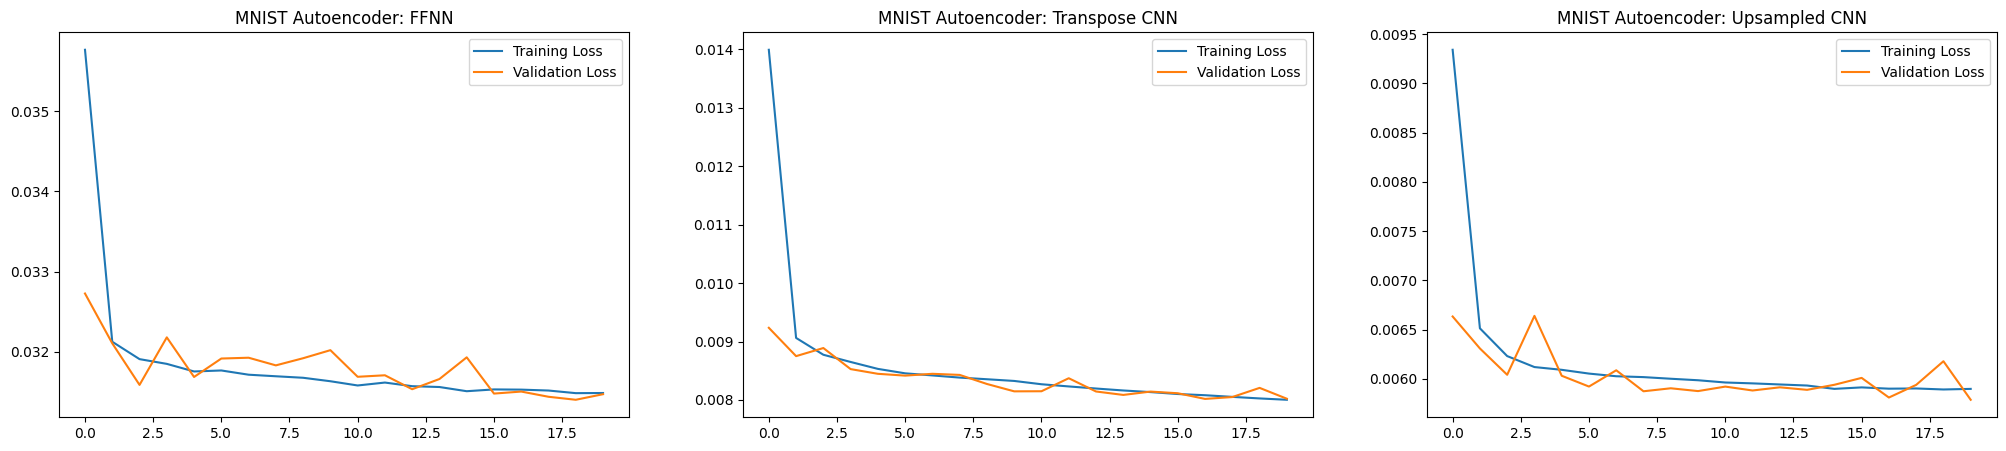

In [ ]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [30]:
def test(model, state='fully', denoising=False, noise_factor=0.2):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    # Keep original images for display later
    original_images_for_display = images.cpu().numpy()

    noisy_images = images # Initialize noisy_images with clean images
    if denoising:
        # Add noise to input images for the autoencoder
        noisy_images = add_gaussian_noise(images, noise_factor)

    # Store noisy images for display
    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images # Model takes noisy images as input
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    # get sample outputs (denoised images)
    output = model(input_to_model)

    # Reshape output to image format and detach for numpy conversion
    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    # plot the original, noisy, and then reconstructed images
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    # Original images on the first row
    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # Noisy images on the second row
    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # Reconstructed (denoised) images on the third row
    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

## FFNN Autoencoder

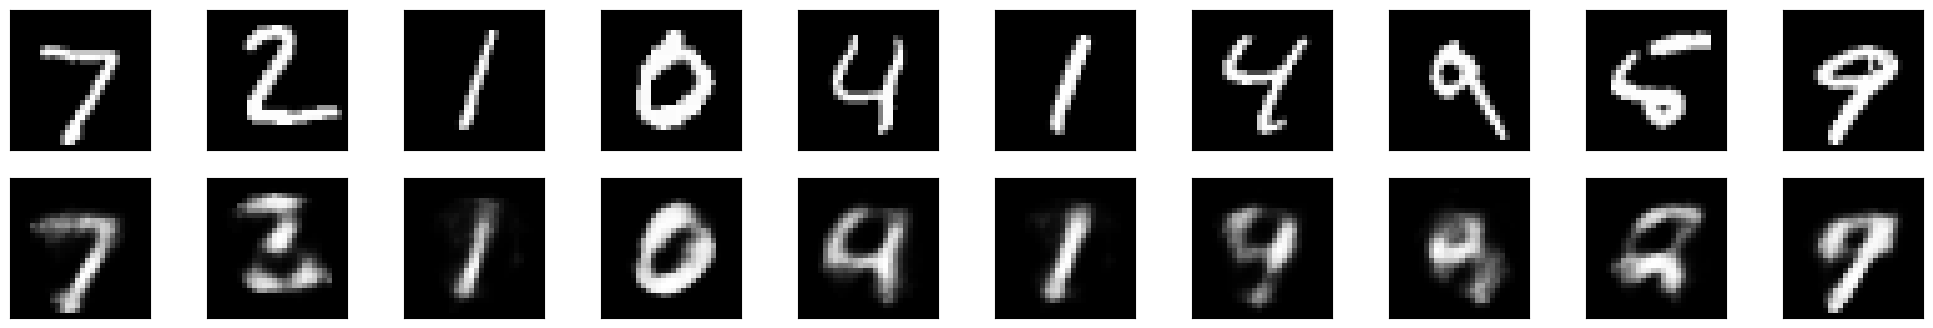

In [ ]:
test(model_1)

## Transpose CNN Autoencoder

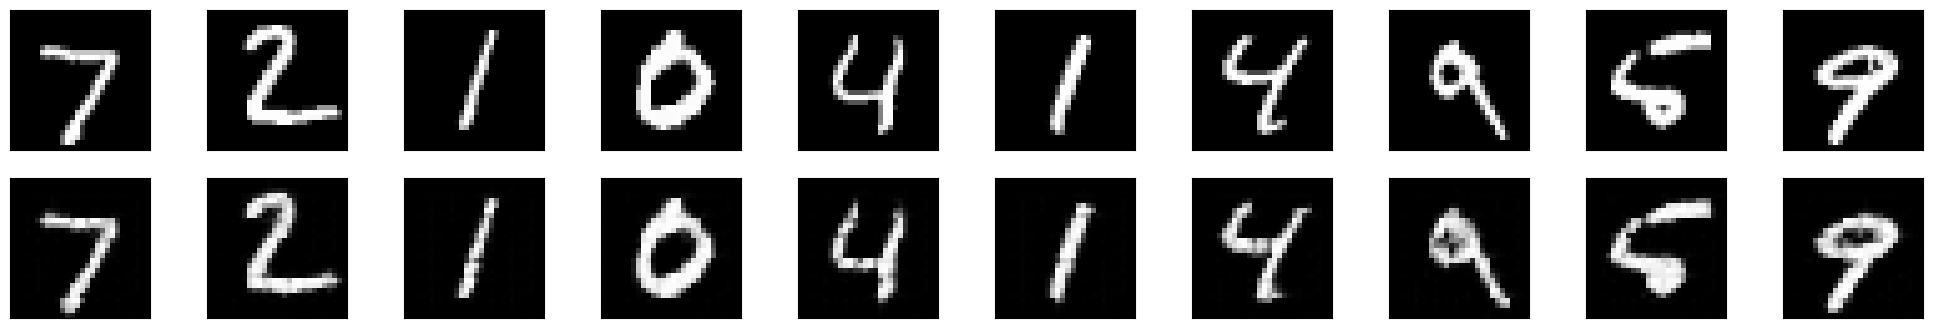

In [ ]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

/tmp/ipykernel_1437/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_1437/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


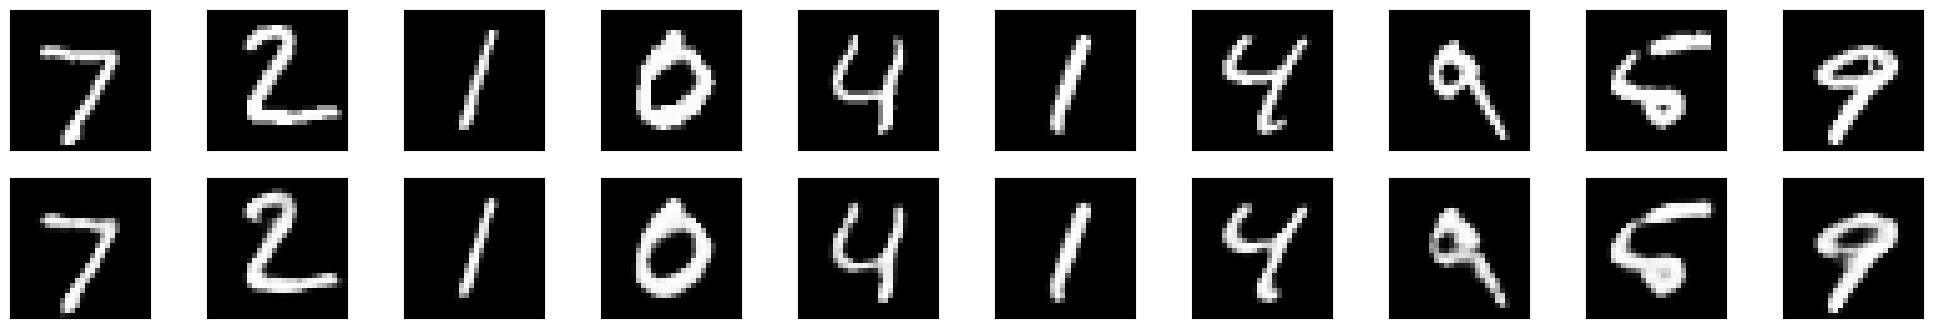

In [ ]:
test(model_3,'conv')

Now, we will modify the `trainNet` function to introduce noise into the input images. The autoencoder will take these noisy images as input and try to reconstruct the original, clean images.

/tmp/ipykernel_2257/4075083271.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_2257/4075083271.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


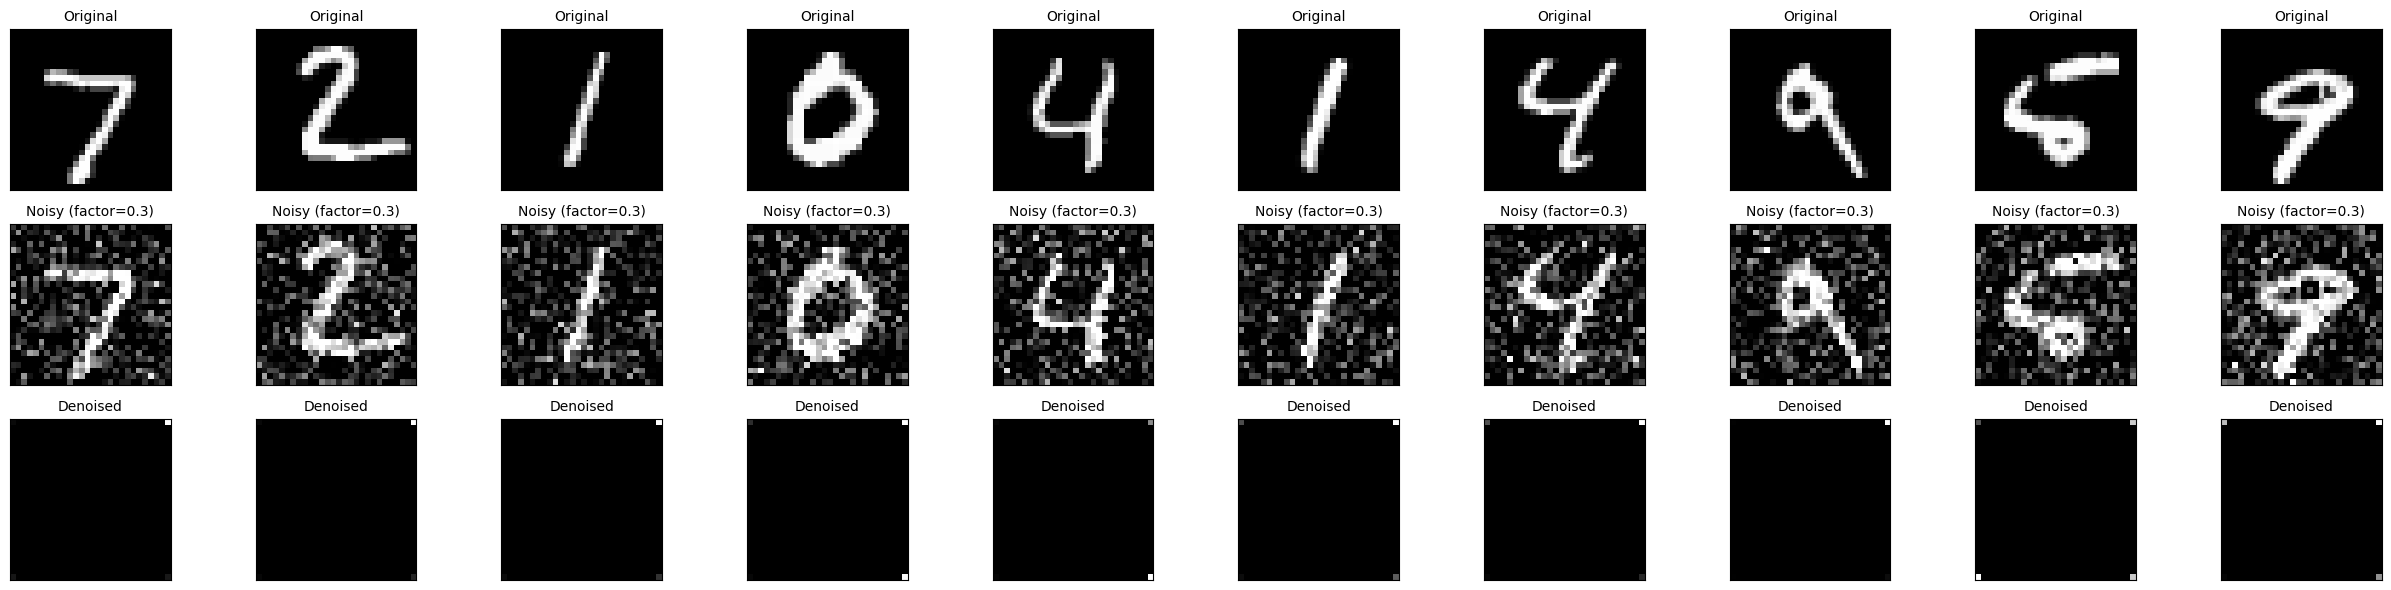

In [32]:
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)

MNIST datasets loaded.
Dataloaders created.
Running models on CPU.

Starting training for upsamp_conv_Auto_MNIST...
Epoch : 1	Training Loss : 0.1122	Validation Loss : 0.1120
Validation loss decreased from : inf ----> 0.1120 ----> Saving Model.......
Epoch : 2	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 3	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 4	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 5	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 6	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 7	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 8	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 9	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 10	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 11	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 12	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 13	Training Loss : 0.1120	Validation Loss : 0.1120
Epoch : 14	Training Loss : 0.1120	Validation Loss 

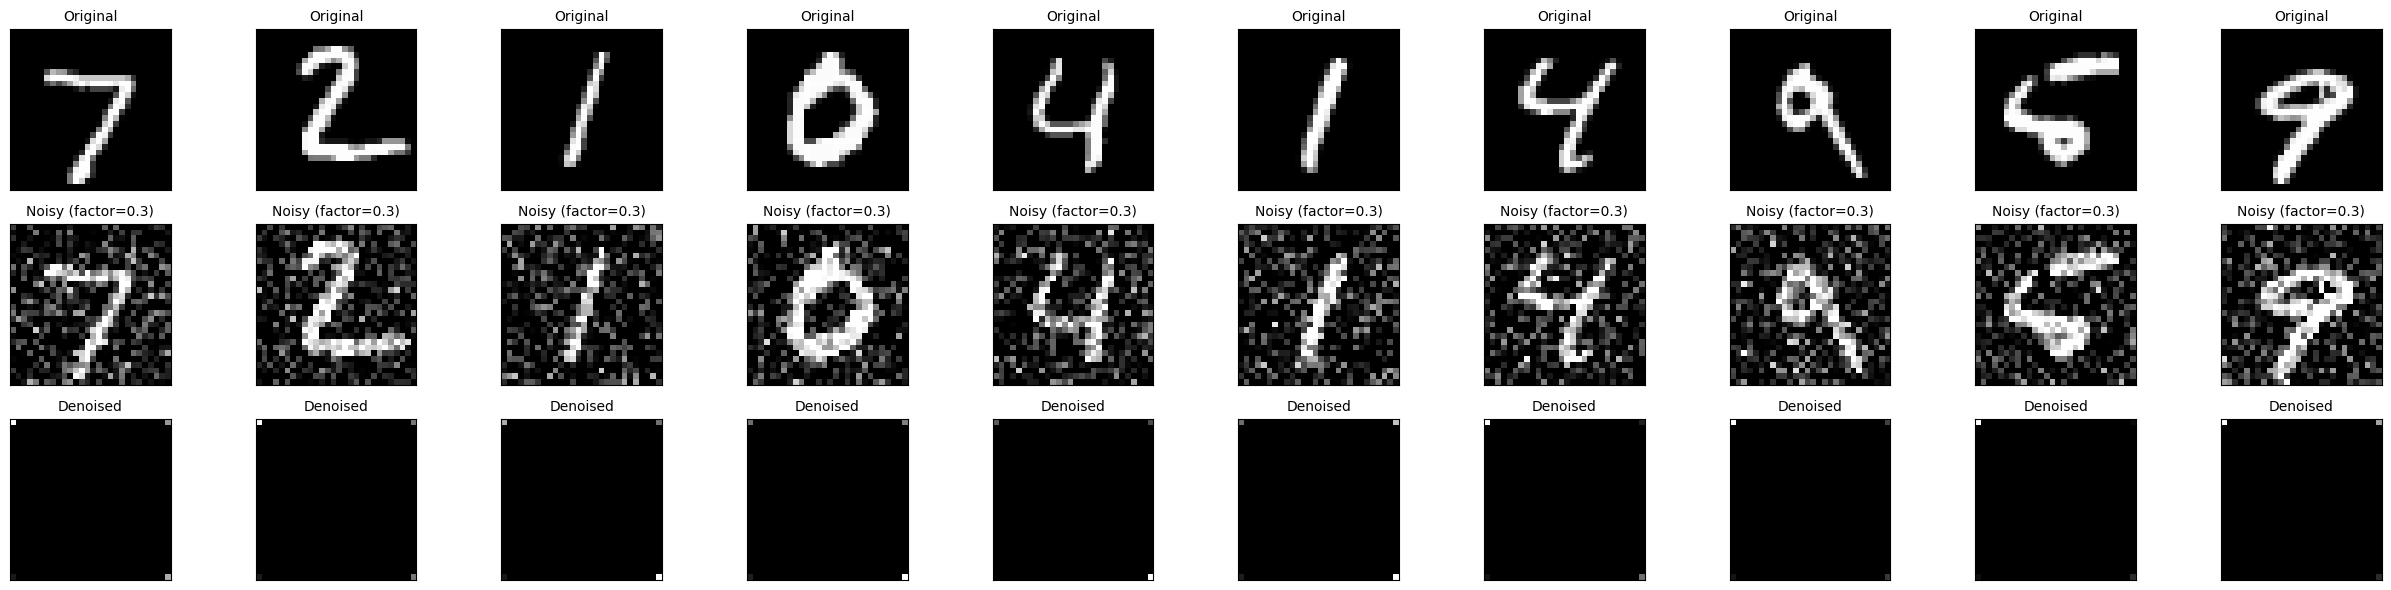

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

# 1. Define transforms
transforms=transforms.ToTensor()

# 2. Download and load MNIST data
print("Downloading MNIST datasets...")
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)
print("MNIST datasets loaded.")

# 3. Utility function to add Gaussian noise
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

# 4. Define dataloaders
valid_size=0.2
batch_size=20
num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)
print("Dataloaders created.")

# 5. Define Autoencoder Architecture Classes
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        # Note: nn.functional.upsample is deprecated. Using nn.functional.interpolate instead.
        x = F.interpolate(x, scale_factor=2, mode='nearest') # Replaced F.upsample
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest') # Replaced F.upsample
        x=F.sigmoid(self.de_conv2(x))
        return x

# 6. Initialize models and setup CUDA
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
  print("Models moved to GPU.")
else:
  print("Running models on CPU.")

# 7. Define Loss Function
criterion=nn.MSELoss()

# 8. Training and Validation Phase Function
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)
    loss_keeper={'train':[],'valid':[]}
    epochs=20
    valid_loss_min = np.inf

    print(f"\nStarting training for {type(model).__name__}...")
    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        model.train()
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        model.eval()
        with torch.no_grad(): # Disable gradient calculations during validation
            for images,_ in valid_loader:
                if use_cuda and torch.cuda.is_available():
                    images=images.cuda()

                original_images = images
                if denoising:
                    images = add_gaussian_noise(images, noise_factor)

                if state=='fully':
                    images=images.view(images.size(0),-1)
                    original_images=original_images.view(original_images.size(0),-1)
                output=model(images)
                loss=criterion(output,original_images)
                valid_loss+=loss.item()

        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"Epoch : {epoch+1}\tTraining Loss : {train_loss:.4f}\tValidation Loss : {valid_loss:.4f}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min:.4f} ----> {valid_loss:.4f} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

# 9. Test function for displaying images
def test(model, state='fully', denoising=False, noise_factor=0.2):
    print(f"\n--- Displaying Test Results for {type(model).__name__} ---")
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    original_images_for_display = images.cpu().numpy()

    noisy_images = images
    if denoising:
        noisy_images = add_gaussian_noise(images, noise_factor)

    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        output = model(input_to_model)

    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# 10. Re-initialize and train model_3 as a denoising autoencoder
# This ensures a fresh training run for the denoising task
model_3_denoising = upsamp_conv_Auto_MNIST()
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

m3_denoising_loss = trainNet(model_3_denoising, 0.01, 'conv', denoising=True, noise_factor=0.3)

# 11. Display denoising results for model_3_denoising
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)


MNIST datasets loaded.
Dataloaders created.
Running models on CPU.

Starting training for upsamp_conv_Auto_MNIST...
Epoch : 1	Training Loss : 0.1123	Validation Loss : 0.1114
Validation loss decreased from : inf ----> 0.1114 ----> Saving Model.......
Epoch : 2	Training Loss : 0.1121	Validation Loss : 0.1114
Validation loss decreased from : 0.1114 ----> 0.1114 ----> Saving Model.......
Epoch : 3	Training Loss : 0.1121	Validation Loss : 0.1114
Epoch : 4	Training Loss : 0.1121	Validation Loss : 0.1114
Validation loss decreased from : 0.1114 ----> 0.1114 ----> Saving Model.......
Epoch : 5	Training Loss : 0.1121	Validation Loss : 0.1114
Validation loss decreased from : 0.1114 ----> 0.1114 ----> Saving Model.......
Epoch : 6	Training Loss : 0.1121	Validation Loss : 0.1114
Epoch : 7	Training Loss : 0.1121	Validation Loss : 0.1114
Epoch : 8	Training Loss : 0.1121	Validation Loss : 0.1114
Validation loss decreased from : 0.1114 ----> 0.1114 ----> Saving Model.......
Epoch : 9	Training Loss : 0.

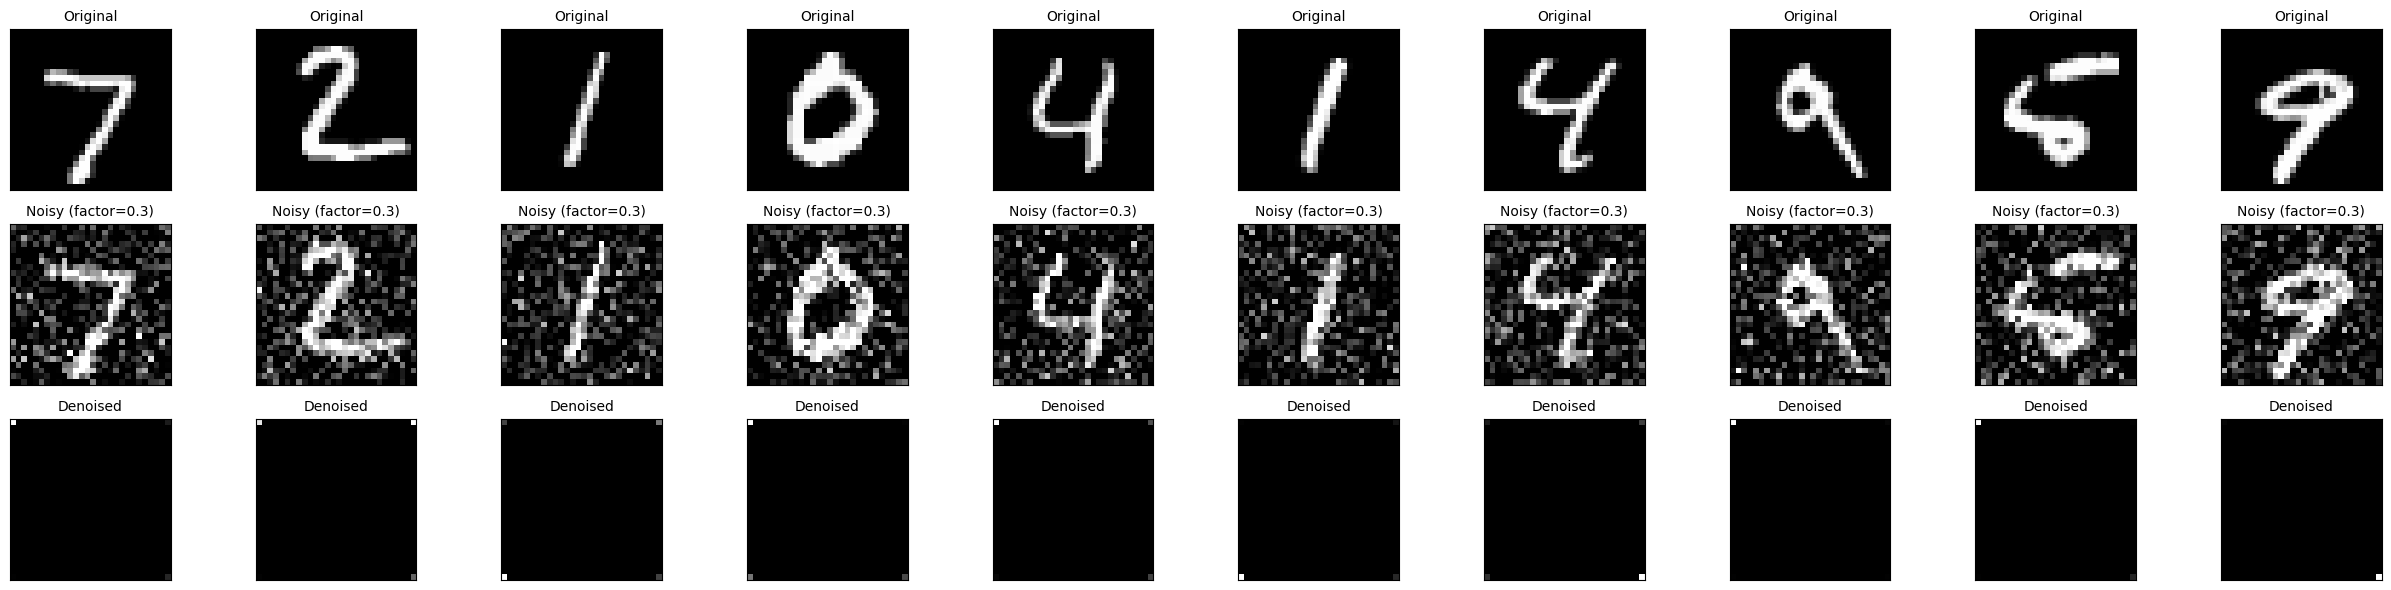

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

# 1. Define transforms
transforms=transforms.ToTensor()

# 2. Download and load MNIST data
print("Downloading MNIST datasets...")
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)
print("MNIST datasets loaded.")

# 3. Utility function to add Gaussian noise
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

# 4. Define dataloaders
valid_size=0.2
batch_size=20
num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)
print("Dataloaders created.")

# 5. Define Autoencoder Architecture Classes
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        # Note: nn.functional.upsample is deprecated. Using nn.functional.interpolate instead.
        x = F.interpolate(x, scale_factor=2, mode='nearest') # Replaced F.upsample
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest') # Replaced F.upsample
        x=F.sigmoid(self.de_conv2(x))
        return x

# 6. Initialize models and setup CUDA
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
  print("Models moved to GPU.")
else:
  print("Running models on CPU.")

# 7. Define Loss Function
criterion=nn.MSELoss()

# 8. Training and Validation Phase Function
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)
    loss_keeper={'train':[],'valid':[]}
    epochs=20
    valid_loss_min = np.inf

    print(f"\nStarting training for {type(model).__name__}...")
    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        model.train()
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        model.eval()
        with torch.no_grad(): # Disable gradient calculations during validation
            for images,_ in valid_loader:
                if use_cuda and torch.cuda.is_available():
                    images=images.cuda()

                original_images = images
                if denoising:
                    images = add_gaussian_noise(images, noise_factor)

                if state=='fully':
                    images=images.view(images.size(0),-1)
                    original_images=original_images.view(original_images.size(0),-1)
                output=model(images)
                loss=criterion(output,original_images)
                valid_loss+=loss.item()

        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"Epoch : {epoch+1}\tTraining Loss : {train_loss:.4f}\tValidation Loss : {valid_loss:.4f}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min:.4f} ----> {valid_loss:.4f} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

# 9. Test function for displaying images
def test(model, state='fully', denoising=False, noise_factor=0.2):
    print(f"\n--- Displaying Test Results for {type(model).__name__} ---")
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    original_images_for_display = images.cpu().numpy()

    noisy_images = images
    if denoising:
        noisy_images = add_gaussian_noise(images, noise_factor)

    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        output = model(input_to_model)

    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# 10. Re-initialize and train model_3 as a denoising autoencoder
# This ensures a fresh training run for the denoising task
model_3_denoising = upsamp_conv_Auto_MNIST()
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

m3_denoising_loss = trainNet(model_3_denoising, 0.01, 'conv', denoising=True, noise_factor=0.3)

# 11. Display denoising results for model_3_denoising
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

# Defining transforms
transforms=transforms.ToTensor()

# Downloading required data
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

# Function to add Gaussian noise
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

# Defining dataloaders
valid_size=0.2
batch_size=20
num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

# Defining Architecture Classes
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

# Initialize models (if not already done)
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()

# Defining our Loss Function
criterion=nn.MSELoss()

# Training and Validation Phase Function
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)
    loss_keeper={'train':[],'valid':[]}
    epochs=20
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        model.train()
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        model.eval()
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            output=model(images)
            loss=criterion(output,original_images)
            valid_loss+=loss.item()

        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model......."
            )
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

# Test function for displaying images
def test(model, state='fully', denoising=False, noise_factor=0.2):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    original_images_for_display = images.cpu().numpy()

    noisy_images = images
    if denoising:
        noisy_images = add_gaussian_noise(images, noise_factor)

    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    output = model(input_to_model)

    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# Re-initialize model_3 for denoising training
model_3_denoising = upsamp_conv_Auto_MNIST()

# Move model to GPU if available
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

# Train model_3 as a denoising autoencoder
print("\n--- Training Denoising Autoencoder (model_3_denoising) ---")
m3_denoising_loss = trainNet(model_3_denoising, 0.01, 'conv', denoising=True, noise_factor=0.3)

# Display denoising results
print("\n--- Displaying Denoising Results ---")
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)



--- Training Denoising Autoencoder (model_3_denoising) ---


/tmp/ipykernel_2257/277274222.py:89: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_2257/277274222.py:91: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.1121489883152147	Validation Loss : 0.11181112627188365
Validation loss decreased from : inf ----> 0.11181112627188365 ----> Saving Model.......

Epoch : 2	Training Loss : 0.1120504427763323	Validation Loss : 0.1118111261477073
Validation loss decreased from : 0.11181112627188365 ----> 0.1118111261477073 ----> Saving Model.......

Epoch : 3	Training Loss : 0.11205044288188219	Validation Loss : 0.11181112606078386
Validation loss decreased from : 0.1118111261477073 ----> 0.11181112606078386 ----> Saving Model.......

Epoch : 4	Training Loss : 0.11205044272976616	Validation Loss : 0.11181112630913655

Epoch : 5	Training Loss : 0.11205044298122327	Validation Loss : 0.11181112617254257

Epoch : 6	Training Loss : 0.112050442956388	Validation Loss : 0.11181112613528967

Epoch : 7	Training Loss : 0.1120504431022952	Validation Loss : 0.11181112613528967

Epoch : 8	Training Loss : 0.11205044304020703	Validation Loss : 0.11181112598627806
Validation loss decreased fro

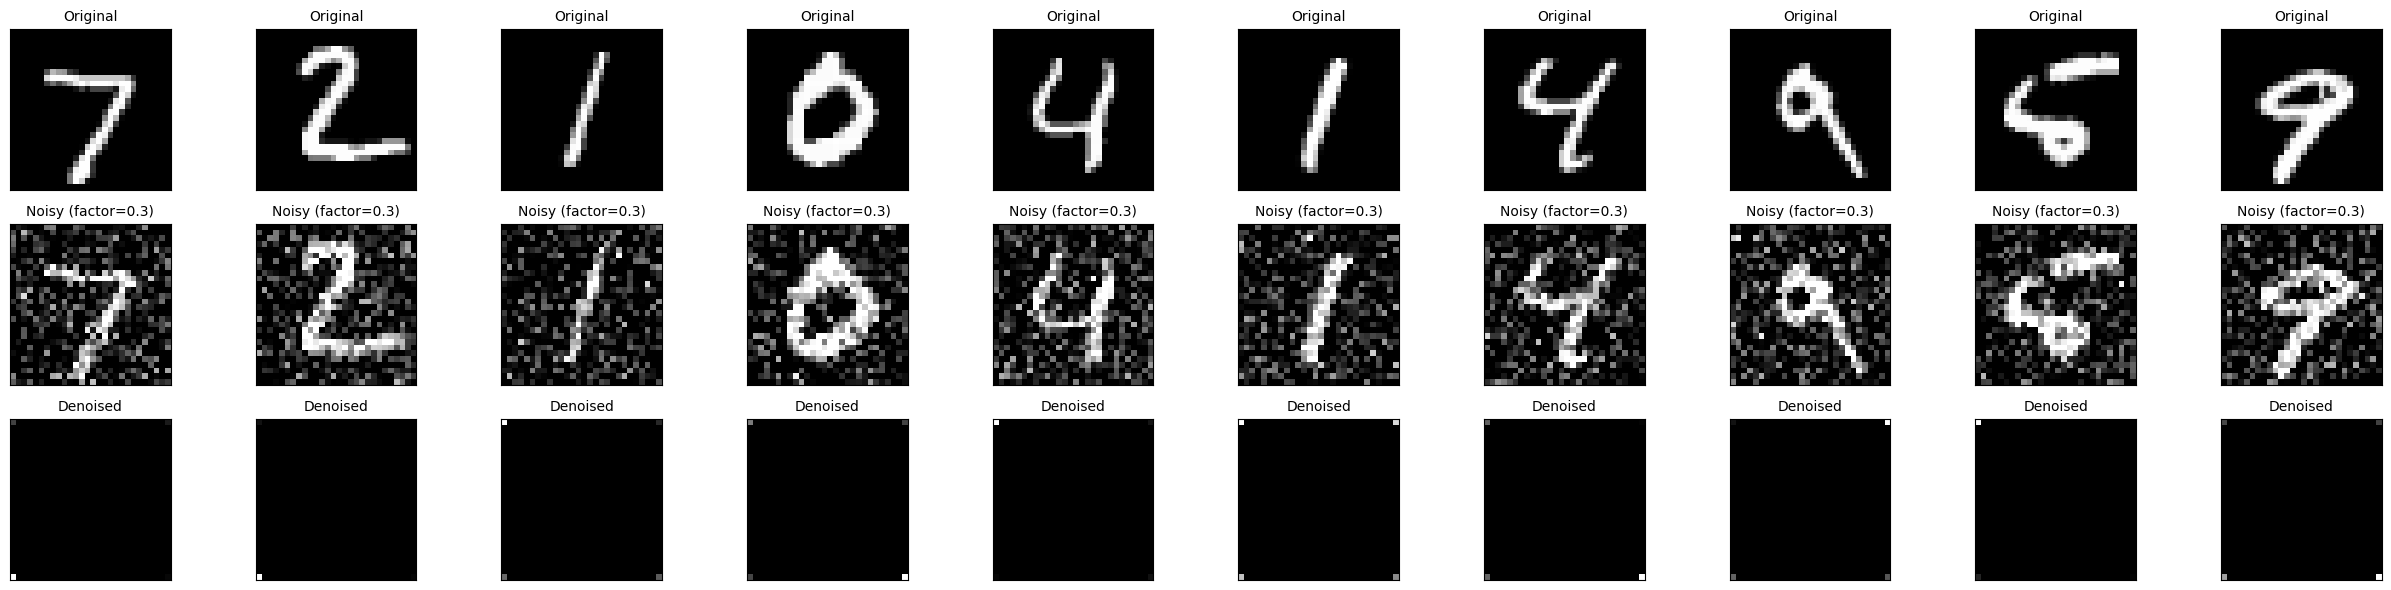

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

# Defining transforms
transforms=transforms.ToTensor()

# Downloading required data
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

# Function to add Gaussian noise
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

# Defining dataloaders
valid_size=0.2
batch_size=20
num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

# Defining Architecture Classes
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

# Initialize models (if not already done)
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()

# Defining our Loss Function
criterion=nn.MSELoss()

# Training and Validation Phase Function
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)
    loss_keeper={'train':[],'valid':[]}
    epochs=20
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        model.train()
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        model.eval()
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images
            if denoising:
                images = add_gaussian_noise(images, noise_factor)

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            output=model(images)
            loss=criterion(output,original_images)
            valid_loss+=loss.item()

        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model......."
            )
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

# Test function for displaying images
def test(model, state='fully', denoising=False, noise_factor=0.2):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    original_images_for_display = images.cpu().numpy()

    noisy_images = images
    if denoising:
        noisy_images = add_gaussian_noise(images, noise_factor)

    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    output = model(input_to_model)

    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# Re-initialize model_3 for denoising training
model_3_denoising = upsamp_conv_Auto_MNIST()

# Move model to GPU if available
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

# Train model_3 as a denoising autoencoder
print("\n--- Training Denoising Autoencoder (model_3_denoising) ---")
m3_denoising_loss = trainNet(model_3_denoising, 0.01, 'conv', denoising=True, noise_factor=0.3)

# Display denoising results
print("\n--- Displaying Denoising Results ---")
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)
